# Critical Scale Invariance in a Healthy Human Heart Rate



1. Load RR-interval data
2. Build the normalized heartbeat series $b(i)$ and the cumulative series $B(i)$
3. Perform local polynomial detrending and compute detrended increments $\Delta_s B(i)$
4. Build probability density functions (PDFs) at several scales
5. Compare Gaussian and non-Gaussian fits
6. Test scale invariance with a collapse plot
7. Strengthen the analysis with pooled multi-subject results



## Dataset

This database includes beat annotation files for 54 long-term ECG recordings of subjects in normal sinus rhythm (30 men, aged 28.5 to 76, and 24 women, aged 58 to 73). The original ECG recordings (not available) were digitized at 128 samples per second, and the beat annotations were obtained by automated analysis with manual review and correction.

Reference: https://physionet.org/content/nsr2db/1.0.0/
Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P.C., Mark, R., Mietus, J.E., Moody, G.B., Peng, C.K. and Stanley, H.E., 2000. PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

## Load data and imports

In [19]:
from utils import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm

data_dir = "physionet.org/files/nsr2db/1.0.0"
rr_data = load_rr_intervals(data_dir)

print(f"Loaded {len(rr_data)} records.")
print("Example records:", list(rr_data.keys())[:5])

  nsr001: 106464 beats, mean HR = 79.0 bpm
  nsr002: 111334 beats, mean HR = 79.5 bpm
  nsr003: 97585 beats, mean HR = 69.3 bpm
  nsr004: 97821 beats, mean HR = 70.5 bpm
  nsr005: 116773 beats, mean HR = 81.7 bpm
  nsr006: 102662 beats, mean HR = 74.3 bpm
  nsr007: 106792 beats, mean HR = 76.1 bpm
  nsr008: 107739 beats, mean HR = 75.4 bpm
  nsr009: 102861 beats, mean HR = 71.8 bpm
  nsr010: 96252 beats, mean HR = 70.1 bpm
  nsr011: 115900 beats, mean HR = 81.5 bpm
  nsr012: 98905 beats, mean HR = 69.1 bpm
  nsr013: 115757 beats, mean HR = 82.3 bpm
  nsr014: 111896 beats, mean HR = 78.2 bpm
  nsr015: 100961 beats, mean HR = 75.9 bpm
  nsr016: 94767 beats, mean HR = 77.2 bpm
  nsr017: 100959 beats, mean HR = 70.4 bpm
  nsr018: 107982 beats, mean HR = 77.3 bpm
  nsr019: 122822 beats, mean HR = 85.7 bpm
  nsr020: 136481 beats, mean HR = 97.7 bpm
  nsr021: 103875 beats, mean HR = 72.5 bpm
  nsr022: 81720 beats, mean HR = 57.8 bpm
  nsr023: 112094 beats, mean HR = 78.2 bpm
  nsr024: 101102 

## Step 1: Build the cumulative time series $B(i)$ from the normalized heartbeat series $b(i)$

For each record:
- compute the mean and standard deviation of the RR intervals
- normalize the signal to get $b(i)$
- integrate it to obtain the cumulative signal

$$
b(i) = \frac{RR_i - \mu}{\sigma}, \qquad
B(i) = \sum_{k=1}^{i} b(k)
$$

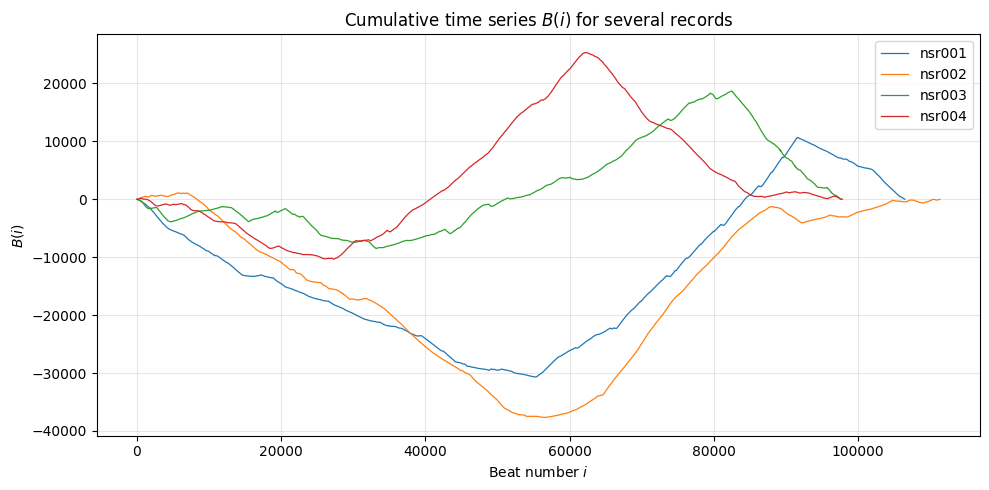

In [20]:
# Dictionaries to store the normalized and cumulative time series
b_data = {}
B_data = {}

for record_name, rr in rr_data.items():
    mu = np.mean(rr)
    sigma = np.std(rr)

    b_i = (rr - mu) / sigma
    B_i = np.cumsum(b_i)

    b_data[record_name] = b_i
    B_data[record_name] = B_i

records_to_plot = list(B_data.keys())[:4]

plt.figure(figsize=(10, 5))
for record_name in records_to_plot:
    plt.plot(B_data[record_name], lw=0.9, label=record_name)

plt.title("Cumulative time series $B(i)$ for several records")
plt.xlabel("Beat number $i$")
plt.ylabel("$B(i)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Steps 2 and 3: Local polynomial detrending and detrended increments

For a chosen scale $s$, the method:
- takes a local window of length $2s$
- fits a polynomial trend inside that window
- subtracts the trend to obtain the detrended signal $B^*(i)$
- computes the increment across the first half-window

$$
\Delta_s B(i) = B^*(i+s) - B^*(i)
$$

We use a third-order polynomial, which is consistent with the article.

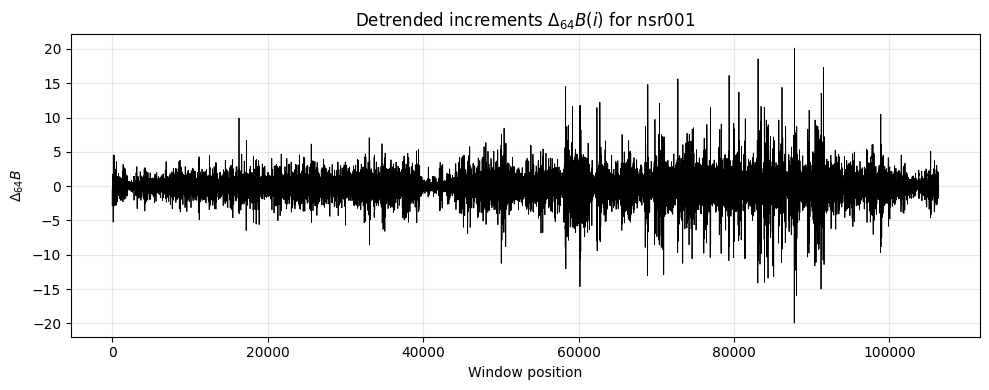

In [21]:
def get_detrended_increments(B_array: np.ndarray, s: int, order: int = 3):
    """Compute detrended increments Δ_s B(i) using sliding windows of size 2s."""
    N = len(B_array)
    window_size = 2 * s
    x = np.arange(window_size)
    increments = []

    for i in range(N - window_size + 1):
        window_data = B_array[i:i + window_size]
        coeffs = np.polyfit(x, window_data, order)
        poly_trend = np.polyval(coeffs, x)
        B_star = window_data - poly_trend
        increments.append(B_star[s] - B_star[0])

    return np.array(increments)

# Example at one scale for one subject
s_example = 64
example_record = list(B_data.keys())[0]
delta_B_example = get_detrended_increments(B_data[example_record], s=s_example, order=3)

plt.figure(figsize=(10, 4))
plt.plot(delta_B_example, lw=0.6, color="black")
plt.title(rf"Detrended increments $\Delta_{{{s_example}}} B(i)$ for {example_record}")
plt.xlabel("Window position")
plt.ylabel(rf"$\Delta_{{{s_example}}} B$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Explicit view of the local polynomial trend

This figure makes the detrending step visible:
- top: one local window of $B(i)$ and its fitted polynomial trend
- bottom: the detrended signal $B^*(i)$, with the two points used to compute the increment

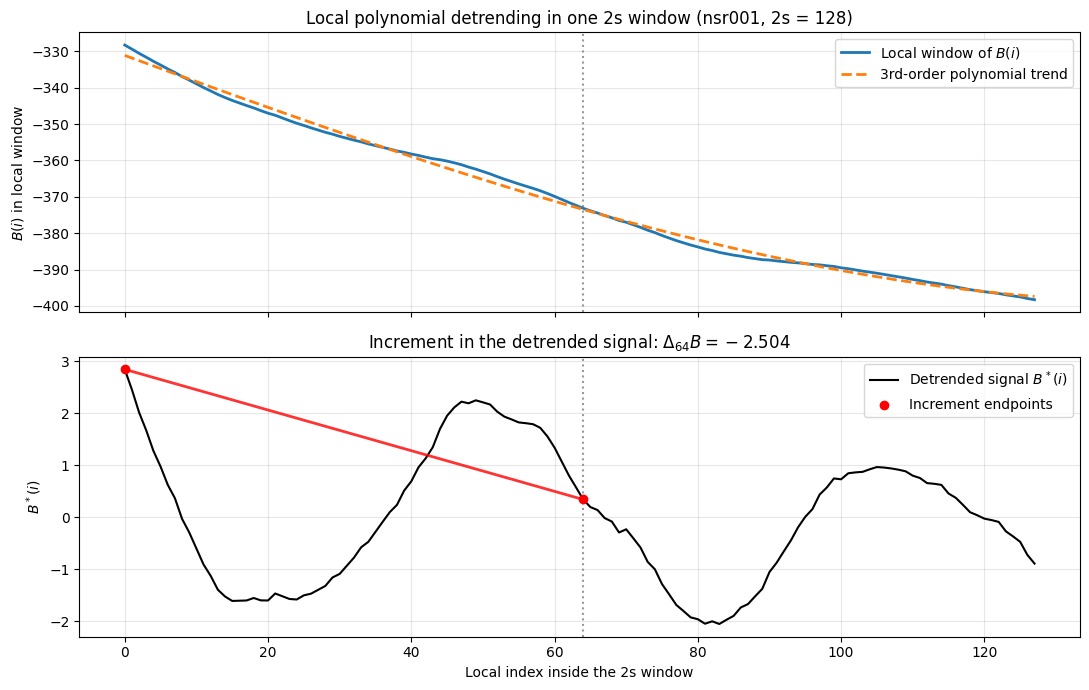

In [22]:
sample_record = list(B_data.keys())[0]
sample_s = 64
sample_order = 3
sample_start = 500

B_sample = B_data[sample_record]
window_size = 2 * sample_s
x_local = np.arange(window_size)
window_data = B_sample[sample_start:sample_start + window_size]

coeffs_local = np.polyfit(x_local, window_data, sample_order)
poly_local = np.polyval(coeffs_local, x_local)
B_star_local = window_data - poly_local
delta_local = B_star_local[sample_s] - B_star_local[0]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(x_local, window_data, lw=2, label="Local window of $B(i)$")
axes[0].plot(x_local, poly_local, "--", lw=2, label="3rd-order polynomial trend")
axes[0].axvline(sample_s, color="gray", ls=":", alpha=0.8)
axes[0].set_title(f"Local polynomial detrending in one 2s window ({sample_record}, 2s = {window_size})")
axes[0].set_ylabel("$B(i)$ in local window")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_local, B_star_local, color="black", lw=1.5, label=r"Detrended signal $B^*(i)$")
axes[1].scatter([0, sample_s], [B_star_local[0], B_star_local[sample_s]], color="red", zorder=5, label="Increment endpoints")
axes[1].plot([0, sample_s], [B_star_local[0], B_star_local[sample_s]], color="red", lw=2, alpha=0.8)
axes[1].axvline(sample_s, color="gray", ls=":", alpha=0.8)
axes[1].set_title(rf"Increment in the detrended signal: $\Delta_{{{sample_s}}} B = {delta_local:.3f}$")
axes[1].set_xlabel("Local index inside the 2s window")
axes[1].set_ylabel(r"$B^*(i)$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4: Build PDFs and test for non-Gaussian fat tails

To compare different scales fairly, we standardize the increments:

$$
X_s = \frac{\Delta_s B - \langle \Delta_s B \rangle}{\sigma_s}
$$

We then:
- build the empirical PDF for several scales
- compare the empirical PDF with a Gaussian reference
- fit a q-Gaussian as a practical non-Gaussian alternative
- repeat the analysis across several subjects

In [23]:
scales_to_analyze = [8, 16, 32, 64, 128, 256]
max_records_for_pooling = min(10, len(B_data))
selected_records = list(B_data.keys())[:max_records_for_pooling]

print("Scales used:", scales_to_analyze)
print("Records used for pooled analysis:", selected_records)

def standardize(x):
    x = np.asarray(x)
    return (x - np.mean(x)) / np.std(x)

def compute_pdf(x, bins=120, x_range=None):
    counts, edges = np.histogram(x, bins=bins, range=x_range, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = counts > 0
    return centers[mask], counts[mask]

def q_gaussian(x, A, beta, q):
    base = 1 - (1 - q) * beta * x**2
    base = np.maximum(base, 1e-12)
    return A * base ** (1 / (1 - q))

def fit_q_gaussian(std_increments):
    x_pdf, y_pdf = compute_pdf(std_increments, bins=150, x_range=(-8, 8))
    popt, _ = curve_fit(
        q_gaussian,
        x_pdf,
        y_pdf,
        p0=[0.4, 0.5, 1.2],
        bounds=([0.0, 0.0, 1.001], [10.0, 10.0, 2.95]),
        maxfev=20000
    )
    y_q = q_gaussian(x_pdf, *popt)
    y_g = norm.pdf(x_pdf, loc=0, scale=1)
    rss_q = np.sum((y_pdf - y_q) ** 2)
    rss_g = np.sum((y_pdf - y_g) ** 2)
    return x_pdf, y_pdf, popt, rss_g, rss_q

Scales used: [8, 16, 32, 64, 128, 256]
Records used for pooled analysis: ['nsr001', 'nsr002', 'nsr003', 'nsr004', 'nsr005', 'nsr006', 'nsr007', 'nsr008', 'nsr009', 'nsr010']


### PDFs at several scales for one subject

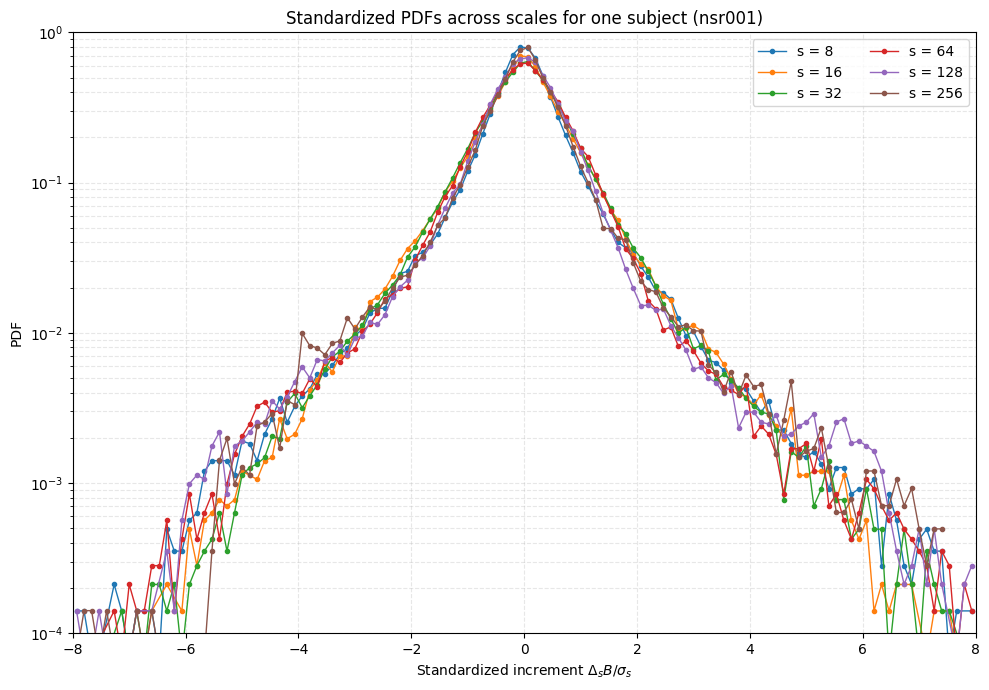

In [24]:
single_record = list(B_data.keys())[0]
single_subject_increments = {}

for s in scales_to_analyze:
    increments_s = get_detrended_increments(B_data[single_record], s=s, order=3)
    single_subject_increments[s] = standardize(increments_s)

plt.figure(figsize=(10, 7))
for s in scales_to_analyze:
    x_pdf, y_pdf = compute_pdf(single_subject_increments[s], bins=120, x_range=(-8, 8))
    plt.plot(x_pdf, y_pdf, marker="o", ms=3, lw=1, label=f"s = {s}")

plt.yscale("log")
plt.xlim(-8, 8)
plt.ylim(1e-4, 1)
plt.title(f"Standardized PDFs across scales for one subject ({single_record})")
plt.xlabel(r"Standardized increment $\Delta_s B / \sigma_s$")
plt.ylabel("PDF")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

### Gaussian vs non-Gaussian comparison at several scales for one subject

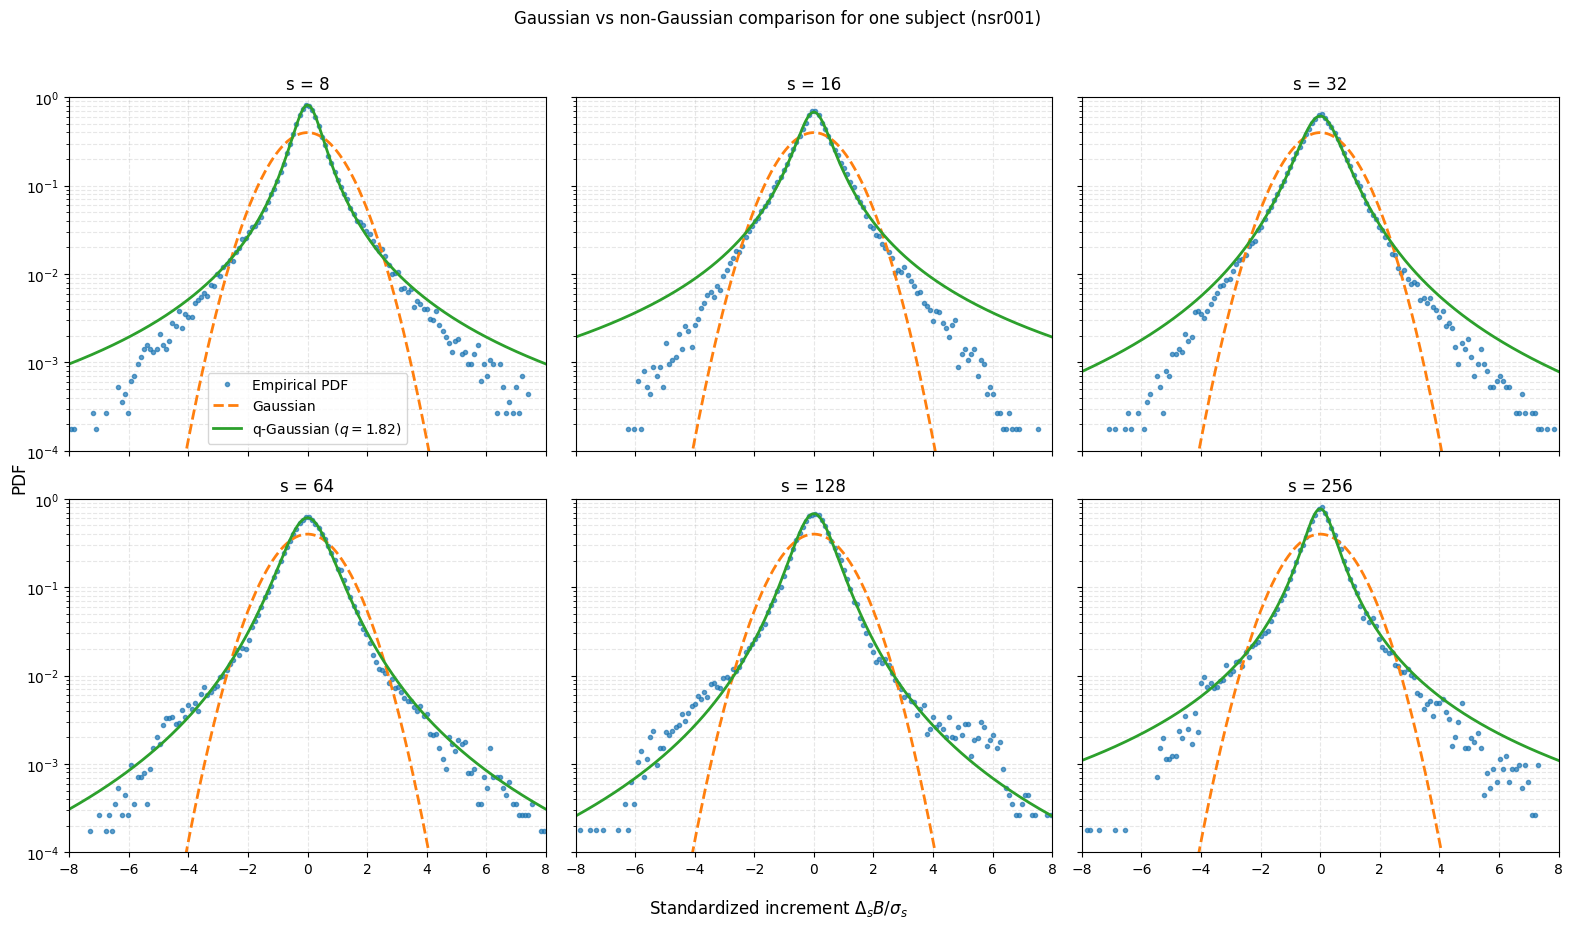

Fit summary for one subject
s=  8 | RSS Gaussian=0.898713 | RSS q-Gaussian=0.002585 | q=1.817 | q-Gaussian better
s= 16 | RSS Gaussian=0.440900 | RSS q-Gaussian=0.009181 | q=1.903 | q-Gaussian better
s= 32 | RSS Gaussian=0.310907 | RSS q-Gaussian=0.004337 | q=1.690 | q-Gaussian better
s= 64 | RSS Gaussian=0.322628 | RSS q-Gaussian=0.002882 | q=1.561 | q-Gaussian better
s=128 | RSS Gaussian=0.525729 | RSS q-Gaussian=0.003281 | q=1.574 | q-Gaussian better
s=256 | RSS Gaussian=0.742102 | RSS q-Gaussian=0.008305 | q=1.822 | q-Gaussian better


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

fit_summary_single = []

for ax, s in zip(axes, scales_to_analyze):
    std_inc = single_subject_increments[s]
    x_pdf, y_pdf, popt, rss_g, rss_q = fit_q_gaussian(std_inc)
    fit_summary_single.append((s, rss_g, rss_q, popt[2]))

    x_plot = np.linspace(-8, 8, 500)
    ax.plot(x_pdf, y_pdf, "o", ms=3, alpha=0.7, label="Empirical PDF")
    ax.plot(x_plot, norm.pdf(x_plot, 0, 1), "--", lw=2, label="Gaussian")
    ax.plot(x_plot, q_gaussian(x_plot, *popt), "-", lw=2, label=fr"q-Gaussian ($q={popt[2]:.2f}$)")
    ax.set_yscale("log")
    ax.set_xlim(-8, 8)
    ax.set_ylim(1e-4, 1)
    ax.set_title(f"s = {s}")
    ax.grid(True, alpha=0.3, which="both", ls="--")

axes[0].legend()
fig.suptitle(f"Gaussian vs non-Gaussian comparison for one subject ({single_record})", y=1.02)
fig.supxlabel(r"Standardized increment $\Delta_s B / \sigma_s$")
fig.supylabel("PDF")
plt.tight_layout()
plt.show()

print("Fit summary for one subject")
for s, rss_g, rss_q, q_value in fit_summary_single:
    verdict = "q-Gaussian better" if rss_q < rss_g else "Gaussian better"
    print(f"s={s:>3} | RSS Gaussian={rss_g:.6f} | RSS q-Gaussian={rss_q:.6f} | q={q_value:.3f} | {verdict}")

### Pooled multi-subject analysis

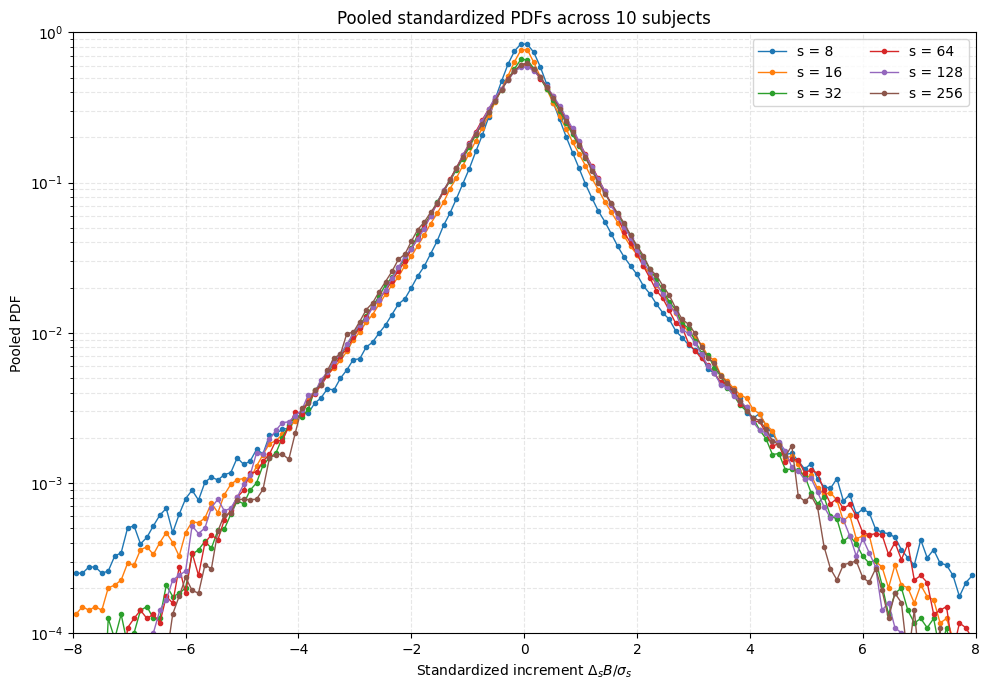

In [26]:
pooled_increments = {s: [] for s in scales_to_analyze}

for record in selected_records:
    B_record = B_data[record]
    for s in scales_to_analyze:
        inc = get_detrended_increments(B_record, s=s, order=3)
        pooled_increments[s].append(standardize(inc))

for s in scales_to_analyze:
    pooled_increments[s] = np.concatenate(pooled_increments[s])

plt.figure(figsize=(10, 7))
for s in scales_to_analyze:
    x_pdf, y_pdf = compute_pdf(pooled_increments[s], bins=140, x_range=(-8, 8))
    plt.plot(x_pdf, y_pdf, marker="o", ms=3, lw=1, label=f"s = {s}")

plt.yscale("log")
plt.xlim(-8, 8)
plt.ylim(1e-4, 1)
plt.title(f"Pooled standardized PDFs across {len(selected_records)} subjects")
plt.xlabel(r"Standardized increment $\Delta_s B / \sigma_s$")
plt.ylabel("Pooled PDF")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

## Step 5: Collapse plot and quantitative summary

A cleaner collapse plot is obtained by comparing the PDFs of the standardized increments directly.
If the curves at different scales overlap well, that supports scale invariance.

We also summarize the Gaussian vs q-Gaussian comparison numerically for the pooled data.

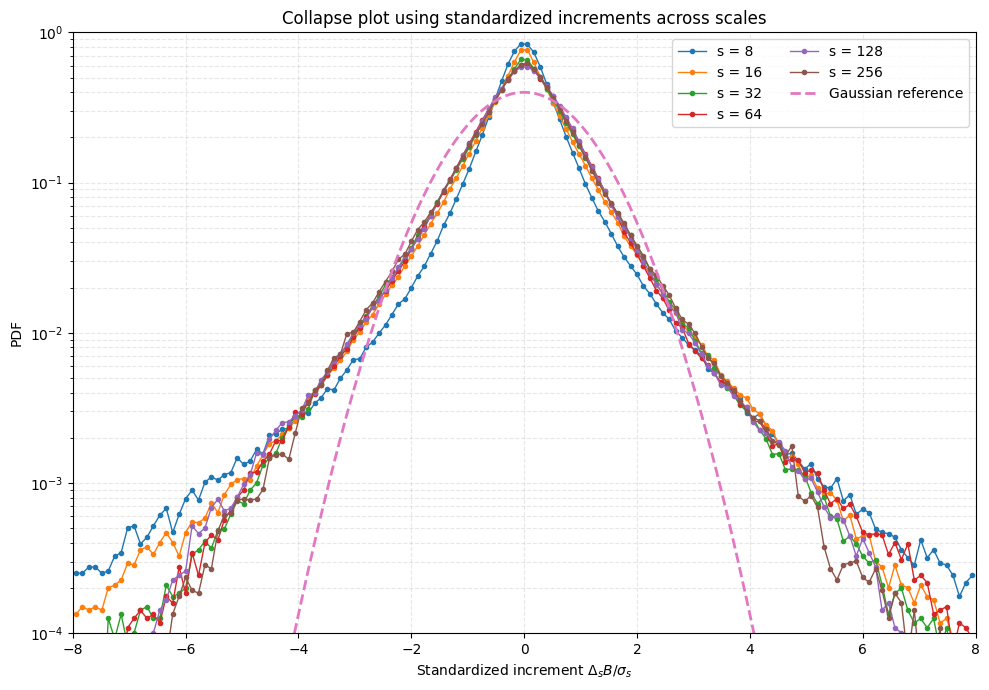

Pooled fit summary across subjects
s=  8 | RSS Gaussian=1.023842 | RSS q-Gaussian=0.001392 | q=1.760 | q-Gaussian better
s= 16 | RSS Gaussian=0.582065 | RSS q-Gaussian=0.012539 | q=1.968 | q-Gaussian better
s= 32 | RSS Gaussian=0.328255 | RSS q-Gaussian=0.008916 | q=1.823 | q-Gaussian better
s= 64 | RSS Gaussian=0.254346 | RSS q-Gaussian=0.004166 | q=1.663 | q-Gaussian better
s=128 | RSS Gaussian=0.233924 | RSS q-Gaussian=0.002458 | q=1.626 | q-Gaussian better
s=256 | RSS Gaussian=0.277717 | RSS q-Gaussian=0.004741 | q=1.751 | q-Gaussian better


In [27]:
plt.figure(figsize=(10, 7))

x_ref = np.linspace(-8, 8, 500)
for s in scales_to_analyze:
    x_pdf, y_pdf = compute_pdf(pooled_increments[s], bins=140, x_range=(-8, 8))
    plt.plot(x_pdf, y_pdf, marker="o", ms=3, lw=1, label=f"s = {s}")

plt.plot(x_ref, norm.pdf(x_ref, 0, 1), "--", lw=2, label="Gaussian reference")
plt.yscale("log")
plt.xlim(-8, 8)
plt.ylim(1e-4, 1)
plt.title("Collapse plot using standardized increments across scales")
plt.xlabel(r"Standardized increment $\Delta_s B / \sigma_s$")
plt.ylabel("PDF")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

fit_summary_pooled = []

for s in scales_to_analyze:
    x_pdf, y_pdf, popt, rss_g, rss_q = fit_q_gaussian(pooled_increments[s])
    fit_summary_pooled.append((s, rss_g, rss_q, popt[2]))

print("Pooled fit summary across subjects")
for s, rss_g, rss_q, q_value in fit_summary_pooled:
    verdict = "q-Gaussian better" if rss_q < rss_g else "Gaussian better"
    print(f"s={s:>3} | RSS Gaussian={rss_g:.6f} | RSS q-Gaussian={rss_q:.6f} | q={q_value:.3f} | {verdict}")

## Final interpretation



- Step 1: constructs $b(i)$ and $B(i)$
- Steps 2 and 3: makes local detrending explicit and computes detrended increments
- Step 4: compares PDFs across scales and tests Gaussian vs non-Gaussian behavior
- Step 5: checks scale collapse and strengthens the conclusion with pooled multi-subject analysis

